In [46]:
! pip install nltk
! pip install vaderSentiment
! pip install pytrends
! pip install textblob
! pip install wordcloud
! pip install gensim
! pip install seaborn
! pip install TextBlob
! pip install joblib

In [1]:
import nltk
import logging
import numpy as np
import pandas as pd
import seaborn as sns
from textblob import TextBlob
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

import re
import string
import joblib
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [123]:
!pip install kagglehub
!pip install kaggle

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammadahmedansari/airbnb-dataset")

print("Path to dataset files:", path)

100%|████████████████████████████████████████████| 40.4M/40.4M [00:08<00:00, 5.26MB/s]

Extracting files...


Path to dataset files: C:\Users\lwinm\.cache\kagglehub\datasets\muhammadahmedansari\airbnb-dataset\versions\2


In [11]:
import shutil
import os

path = r"C:\Users\lwinm\.cache\kagglehub\datasets"

if os.path.exists(path):
    shutil.rmtree(path)
    print("Deleted successfully")
else:
    print("Folder does not exist")

Deleted successfully


In [124]:
import os

download_path = r"C:\Users\lwinm\Jupyter\AirBnb Review Analysis"
os.makedirs(download_path, exist_ok=True)

os.chdir(download_path)
# Download dataset
!kaggle datasets download -d muhammadahmedansari/airbnb-dataset

# Unzip
!tar -xf airbnb-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/muhammadahmedansari/airbnb-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
airbnb-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [2]:
df = pd.read_csv('reviews.csv')
df.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,2818.0,1191.0,3/30/2009,10952,Lam,Daniel is really cool. The place was nice and ...
1,515749.0,1671407.0,7/9/2012,2640670,Gregory,If you want the authentic Amsterdam houseboat ...
2,515749.0,1715674.0,7/15/2012,1032804,Michael,Unique and luxurious to be sure. I couldn't re...
3,2818.0,1771.0,4/24/2009,12798,Alice,Daniel is the most amazing host! His place is ...
4,515749.0,1963378.0,8/12/2012,503786,Brian,My wife and I recently stopped in Amsterdam fo...


In [3]:
df.tail()

,listing_id,id,date,reviewer_id,reviewer_name,comments
342899,40606723.0,6.997740e+17,8/23/2022,199478251,Hugo,Excelente ubicación
342900,40606723.0,6.998450e+17,8/23/2022,168768099,Cerys,"Would definitely recommend. Perfect location, ..."
342901,40606723.0,7.004880e+17,8/24/2022,118306945,Anita,"Hôtel bien situé, personnel d’accueil chaleure..."
342902,40606723.0,7.004940e+17,8/24/2022,403631092,Tos,Sehr freundliche Personal. Vom Hotel aus kann ...
342903,40606723.0,7.005040e+17,8/24/2022,467451204,Laura,L’Hotel2Stay si trova in una posizione molto c...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342904 entries, 0 to 342903
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   listing_id     342904 non-null  float64
 1   id             342904 non-null  float64
 2   date           342904 non-null  object 
 3   reviewer_id    342904 non-null  int64  
 4   reviewer_name  342904 non-null  object 
 5   comments       342888 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 15.7+ MB


In [5]:
df.shape

(342904, 6)

In [6]:
df.describe()

,listing_id,id,reviewer_id
count,3.429040e+05,3.429040e+05,3.429040e+05
mean,6.478685e+15,1.561403e+17,1.183357e+08
std,6.292660e+16,2.607990e+17,1.181510e+08
min,2.818000e+03,1.191000e+03,1.041000e+03
25%,3.724060e+06,1.941558e+08,2.615132e+07
50%,1.346011e+07,4.508779e+08,7.477861e+07
75%,2.512124e+07,4.250678e+17,1.764185e+08
max,7.054480e+17,7.107280e+17,4.780576e+08


In [7]:
df.isnull().sum

<bound method DataFrame.sum of         listing_id     id   date  reviewer_id  reviewer_name  comments
0            False  False  False        False          False     False
1            False  False  False        False          False     False
2            False  False  False        False          False     False
3            False  False  False        False          False     False
4            False  False  False        False          False     False
...            ...    ...    ...          ...            ...       ...
342899       False  False  False        False          False     False
342900       False  False  False        False          False     False
342901       False  False  False        False          False     False
342902       False  False  False        False          False     False
342903       False  False  False        False          False     False

[342904 rows x 6 columns]>

In [8]:
df.duplicated().sum

<bound method Series.sum of 0         False
1         False
2         False
3         False
4         False
          ...  
342899    False
342900    False
342901    False
342902    False
342903    False
Length: 342904, dtype: bool>

In [9]:
#Remove URL from texts
def url_remove(text):
    if not isinstance(text, str):
        logging.error("Input must be string")
        raise TypeError("Input must be string")

    url = r'http\S+|www\S+|https\S+'
    clean_text = re.sub(url, '', text, flags=re.MULTILINE)

    return text

#Remove special characters
def char_remove(text):
    if not isinstance(text, str):
        logging.error("Input must be string")
        raise TypeError("Input must be string")

    char = r'\@\w+\#\w+'
    clean_char = re.sub(char, '', text)

    return clean_char

#Remove punctuation
def pun_remove(text):
    if not isinstance(text, str):
        logging.error("Input must be string")
        raise TypeError("Input must be string")

    pun_tran = str.maketrans('', '', string.punctuation)
    clean_pun = text.translate(pun_tran)

    return clean_pun

#Remove stop words
stop_words = set(stopwords.words('english'))

def stop_words_remove(text):
    if not isinstance(text, str):
        logging.error("Input must be string")
        raise TypeError("Input must be string")

    stp_words = [word for word in text.split() if word not in stop_words]
    clean_words = ' '.join(stp_words)

    return clean_words

#Remove numbers
def num_remove(text):
    return re.sub(r'\d+', '', text)

#Remove emojis
def emoji_remove(text):
    emojis = re.compile(pattern="["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F700-\U0001F77F"  # alchemical symbols
                               u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
                               u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
                               u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
                               u"\U0001FA00-\U0001FA6F"  # Chess Symbols
                               u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
                               u"\U00002702-\U000027B0"  # Dingbats
                               u"\U000024C2-\U0001F251"
                               "]+", flags=re.UNICODE)
    return emojis.sub(r'', text)

#Space
def space_space(text):
    return re.sub(r'\s+', ' ', text).strip()

def lemmit(text):
    lemm = nltk.stem.WordNetLemmatizer()
    return ' '.join([lemm.lemmatize(word) for word in text.split()])

def stemmin(text):
    stemm = nltk.stem.PorterStemmer()
    return ' '.join([stemm.stem(word) for word in text.split()])

In [10]:
def clean_text(text):
    text = text.lower()
    text = url_remove(text)
    text = char_remove(text)
    text = pun_remove(text)
    text = stop_words_remove(text)
    text = num_remove(text)
    text = emoji_remove(text)
    text = space_space(text)
    text = lemmit(text)
    text = stemmin(text)

    return text

In [11]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('wordnet', quiet=True)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lwinm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lwinm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lwinm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [12]:
df.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,2818.0,1191.0,3/30/2009,10952,Lam,Daniel is really cool. The place was nice and ...
1,515749.0,1671407.0,7/9/2012,2640670,Gregory,If you want the authentic Amsterdam houseboat ...
2,515749.0,1715674.0,7/15/2012,1032804,Michael,Unique and luxurious to be sure. I couldn't re...
3,2818.0,1771.0,4/24/2009,12798,Alice,Daniel is the most amazing host! His place is ...
4,515749.0,1963378.0,8/12/2012,503786,Brian,My wife and I recently stopped in Amsterdam fo...


In [13]:
df['comments'] = df['comments'].astype(str)

In [14]:
df['clean_comments'] = df['comments'].apply(clean_text)

In [15]:
df.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,clean_comments
0,2818.0,1191.0,3/30/2009,10952,Lam,Daniel is really cool. The place was nice and ...,daniel realli cool place nice clean quiet neig...
1,515749.0,1671407.0,7/9/2012,2640670,Gregory,If you want the authentic Amsterdam houseboat ...,want authent amsterdam houseboat experi great ...
2,515749.0,1715674.0,7/15/2012,1032804,Michael,Unique and luxurious to be sure. I couldn't re...,uniqu luxuri sure couldnt recommend stay derk ...
3,2818.0,1771.0,4/24/2009,12798,Alice,Daniel is the most amazing host! His place is ...,daniel amaz host place extrem clean provid eve...
4,515749.0,1963378.0,8/12/2012,503786,Brian,My wife and I recently stopped in Amsterdam fo...,wife recent stop amsterdam day honeymoon didnt...


In [16]:
df.duplicated().sum()

0

In [17]:
#sentiment analysis
df['polarity'] = df['clean_comments'].apply(
    lambda x: TextBlob(x).sentiment.polarity)

'''
TextBlob is a Python library that simplifies natural language processing (NLP) 
by providing an intuitive API for common text analysis tasks. It builds upon 
Natural Language Toolkit and Pattern, combining their linguistic capabilities 
into a beginner-friendly yet extensible toolset. It is often used for prototyping, 
education, and lightweight NLP applications.
'''

'\nTextBlob is a Python library that simplifies natural language processing (NLP) \nby providing an intuitive API for common text analysis tasks. It builds upon \nNatural Language Toolkit and Pattern, combining their linguistic capabilities \ninto a beginner-friendly yet extensible toolset. It is often used for prototyping, \neducation, and lightweight NLP applications.\n'

In [18]:
df.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,clean_comments,polarity
0,2818.0,1191.0,3/30/2009,10952,Lam,Daniel is really cool. The place was nice and ...,daniel realli cool place nice clean quiet neig...,0.219444
1,515749.0,1671407.0,7/9/2012,2640670,Gregory,If you want the authentic Amsterdam houseboat ...,want authent amsterdam houseboat experi great ...,0.275395
2,515749.0,1715674.0,7/15/2012,1032804,Michael,Unique and luxurious to be sure. I couldn't re...,uniqu luxuri sure couldnt recommend stay derk ...,0.109524
3,2818.0,1771.0,4/24/2009,12798,Alice,Daniel is the most amazing host! His place is ...,daniel amaz host place extrem clean provid eve...,0.366667
4,515749.0,1963378.0,8/12/2012,503786,Brian,My wife and I recently stopped in Amsterdam fo...,wife recent stop amsterdam day honeymoon didnt...,0.228095


In [19]:
df['sentiment'] = pd.cut(df['polarity'], bins=3, labels=['negative', 'neutral', 'positive'])

In [20]:
df.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,clean_comments,polarity,sentiment
0,2818.0,1191.0,3/30/2009,10952,Lam,Daniel is really cool. The place was nice and ...,daniel realli cool place nice clean quiet neig...,0.219444,neutral
1,515749.0,1671407.0,7/9/2012,2640670,Gregory,If you want the authentic Amsterdam houseboat ...,want authent amsterdam houseboat experi great ...,0.275395,neutral
2,515749.0,1715674.0,7/15/2012,1032804,Michael,Unique and luxurious to be sure. I couldn't re...,uniqu luxuri sure couldnt recommend stay derk ...,0.109524,neutral
3,2818.0,1771.0,4/24/2009,12798,Alice,Daniel is the most amazing host! His place is ...,daniel amaz host place extrem clean provid eve...,0.366667,positive
4,515749.0,1963378.0,8/12/2012,503786,Brian,My wife and I recently stopped in Amsterdam fo...,wife recent stop amsterdam day honeymoon didnt...,0.228095,neutral


In [21]:
df['sentiment'].value_counts()

sentiment
positive    188828
neutral     153191
negative       885
Name: count, dtype: int64

In [22]:
df = df.groupby('sentiment').apply(lambda x: x.sample(n=885)).reset_index(
    drop=True).sort_values(by=['sentiment'])

In [23]:
df['sentiment'].value_counts()

sentiment
negative    885
neutral     885
positive    885
Name: count, dtype: int64

In [24]:
df.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,clean_comments,polarity,sentiment
0,3.398077e+07,6.637143e+08,9/13/2020,172211200,Daniel,Das Bad hatte leider keine Fenster und die Dus...,da bad hatt leider kein fenster und die dusch ...,-0.7,negative
584,6.801759e+06,2.473515e+08,3/28/2018,115297671,Julia,Der vermietete Bereich um fasst ein schönes Zi...,der vermietet bereich um fasst ein schöne zimm...,-0.7,negative
585,4.370845e+07,7.564322e+08,5/9/2021,363691026,Mara,We hebben verbleven in een prachtige kamer met...,hebben verbleven een prachtig kamer met een he...,-0.7,negative
586,4.721743e+06,4.113110e+17,7/21/2021,363414086,Paula,Prima kamer in de gezellige jordaan. Met prive...,prima kamer de gezellig jordaan met privebadka...,-0.7,negative
587,6.164640e+17,6.620760e+17,7/2/2022,462104966,Khalid,"Worst experience ever, definitely not coming b...",worst experi ever definit come back,-0.5,negative


In [25]:
df = df.drop(['listing_id', 'id', 'reviewer_id'], axis=1)

In [26]:
df.head()

,date,reviewer_name,comments,clean_comments,polarity,sentiment
0,9/13/2020,Daniel,Das Bad hatte leider keine Fenster und die Dus...,da bad hatt leider kein fenster und die dusch ...,-0.7,negative
584,3/28/2018,Julia,Der vermietete Bereich um fasst ein schönes Zi...,der vermietet bereich um fasst ein schöne zimm...,-0.7,negative
585,5/9/2021,Mara,We hebben verbleven in een prachtige kamer met...,hebben verbleven een prachtig kamer met een he...,-0.7,negative
586,7/21/2021,Paula,Prima kamer in de gezellige jordaan. Met prive...,prima kamer de gezellig jordaan met privebadka...,-0.7,negative
587,7/2/2022,Khalid,"Worst experience ever, definitely not coming b...",worst experi ever definit come back,-0.5,negative


In [27]:
df.isnull().sum() #if not drop again using: df = df.dropna()

date              0
reviewer_name     0
comments          0
clean_comments    0
polarity          0
sentiment         0
dtype: int64

In [28]:
df.duplicated().sum()

0

In [29]:
df = df[df['date'].str.contains('^\d', na=False)] #start with a number if not drop

In [30]:
df['date'] = pd.to_datetime(df['date'])

In [31]:
df.head()

,date,reviewer_name,comments,clean_comments,polarity,sentiment
0,2020-09-13,Daniel,Das Bad hatte leider keine Fenster und die Dus...,da bad hatt leider kein fenster und die dusch ...,-0.7,negative
584,2018-03-28,Julia,Der vermietete Bereich um fasst ein schönes Zi...,der vermietet bereich um fasst ein schöne zimm...,-0.7,negative
585,2021-05-09,Mara,We hebben verbleven in een prachtige kamer met...,hebben verbleven een prachtig kamer met een he...,-0.7,negative
586,2021-07-21,Paula,Prima kamer in de gezellige jordaan. Met prive...,prima kamer de gezellig jordaan met privebadka...,-0.7,negative
587,2022-07-02,Khalid,"Worst experience ever, definitely not coming b...",worst experi ever definit come back,-0.5,negative


In [32]:
df.to_csv(r'C:\Users\lwinm\Jupyter\AirBnb Review Analysis\cleaned_airbnb_review.csv', index=False)

In [33]:
#Start modelling and EDA - Exploratory Data Analysis

In [34]:
import nltk
import logging
import numpy as np
import pandas as pd
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.preprocessing import LabelEncoder


from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import joblib
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [35]:
data = pd.read_csv('cleaned_airbnb_review.csv')

In [36]:
data.head()

,date,reviewer_name,comments,clean_comments,polarity,sentiment
0,2020-09-13,Daniel,Das Bad hatte leider keine Fenster und die Dus...,da bad hatt leider kein fenster und die dusch ...,-0.7,negative
1,2018-03-28,Julia,Der vermietete Bereich um fasst ein schönes Zi...,der vermietet bereich um fasst ein schöne zimm...,-0.7,negative
2,2021-05-09,Mara,We hebben verbleven in een prachtige kamer met...,hebben verbleven een prachtig kamer met een he...,-0.7,negative
3,2021-07-21,Paula,Prima kamer in de gezellige jordaan. Met prive...,prima kamer de gezellig jordaan met privebadka...,-0.7,negative
4,2022-07-02,Khalid,"Worst experience ever, definitely not coming b...",worst experi ever definit come back,-0.5,negative


In [37]:
data.isnull().sum()

date               0
reviewer_name      0
comments           0
clean_comments    15
polarity           0
sentiment          0
dtype: int64

In [38]:
data.duplicated().sum()

0

In [39]:
data.dropna(inplace=True)
data.isnull().sum()

date              0
reviewer_name     0
comments          0
clean_comments    0
polarity          0
sentiment         0
dtype: int64

In [40]:
reviewer_freq =data['reviewer_name'].value_counts()
reviewer_freq

reviewer_name
David            19
Laura            17
Daniel           16
Michael          16
Anne             14
                 ..
Lyla              1
Sonia             1
Manuel            1
Klaus & Hilla     1
Yadava            1
Name: count, Length: 1573, dtype: int64

<Figure size 1000x800 with 0 Axes>

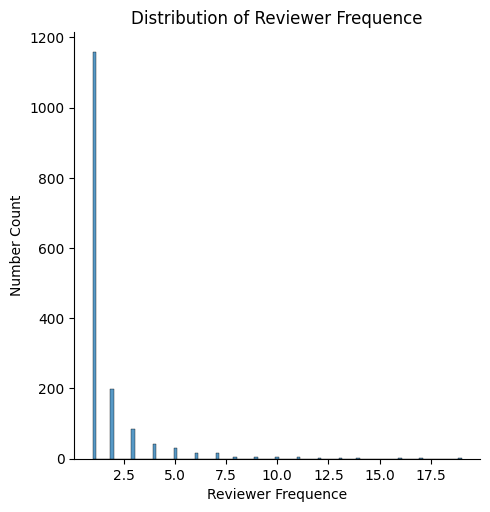

In [41]:
plt.figure(figsize=(10,8))
sns.displot(reviewer_freq, kde=False)
plt.title('Distribution of Reviewer Frequence')
plt.xlabel('Reviewer Frequence')
plt.ylabel('Number Count')
plt.show()

In [42]:
data.head()

,date,reviewer_name,comments,clean_comments,polarity,sentiment
0,2020-09-13,Daniel,Das Bad hatte leider keine Fenster und die Dus...,da bad hatt leider kein fenster und die dusch ...,-0.7,negative
1,2018-03-28,Julia,Der vermietete Bereich um fasst ein schönes Zi...,der vermietet bereich um fasst ein schöne zimm...,-0.7,negative
2,2021-05-09,Mara,We hebben verbleven in een prachtige kamer met...,hebben verbleven een prachtig kamer met een he...,-0.7,negative
3,2021-07-21,Paula,Prima kamer in de gezellige jordaan. Met prive...,prima kamer de gezellig jordaan met privebadka...,-0.7,negative
4,2022-07-02,Khalid,"Worst experience ever, definitely not coming b...",worst experi ever definit come back,-0.5,negative


In [48]:
data['comment_length'] = data['clean_comments'].apply(lambda x: len(x.split()))

In [52]:
data.head()

,date,reviewer_name,comments,clean_comments,polarity,sentiment,comment_length
0,2020-09-13,Daniel,Das Bad hatte leider keine Fenster und die Dus...,da bad hatt leider kein fenster und die dusch ...,-0.7,negative,44
1,2018-03-28,Julia,Der vermietete Bereich um fasst ein schönes Zi...,der vermietet bereich um fasst ein schöne zimm...,-0.7,negative,44
2,2021-05-09,Mara,We hebben verbleven in een prachtige kamer met...,hebben verbleven een prachtig kamer met een he...,-0.7,negative,31
3,2021-07-21,Paula,Prima kamer in de gezellige jordaan. Met prive...,prima kamer de gezellig jordaan met privebadka...,-0.7,negative,21
4,2022-07-02,Khalid,"Worst experience ever, definitely not coming b...",worst experi ever definit come back,-0.5,negative,6


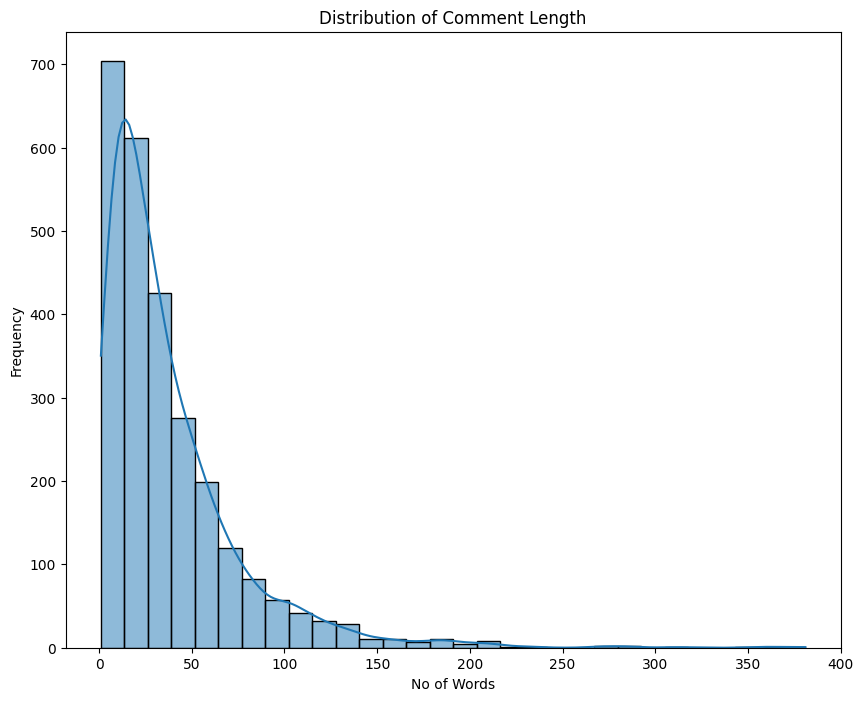

In [53]:
plt.figure(figsize=(10,8))
sns.histplot(data['comment_length'], bins=30, kde=True)
plt.title('Distribution of Comment Length')
plt.xlabel('No of Words')
plt.ylabel('Frequency')
plt.show()

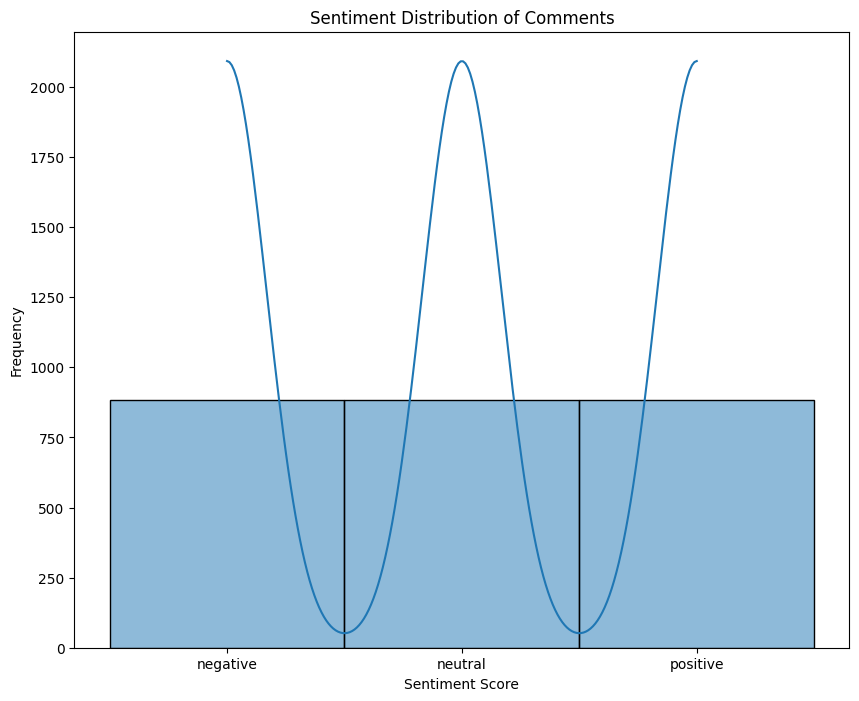

In [54]:
plt.figure(figsize=(10,8))
sns.histplot(df['sentiment'], bins=30, kde=True)
plt.title('Sentiment Distribution of Comments')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

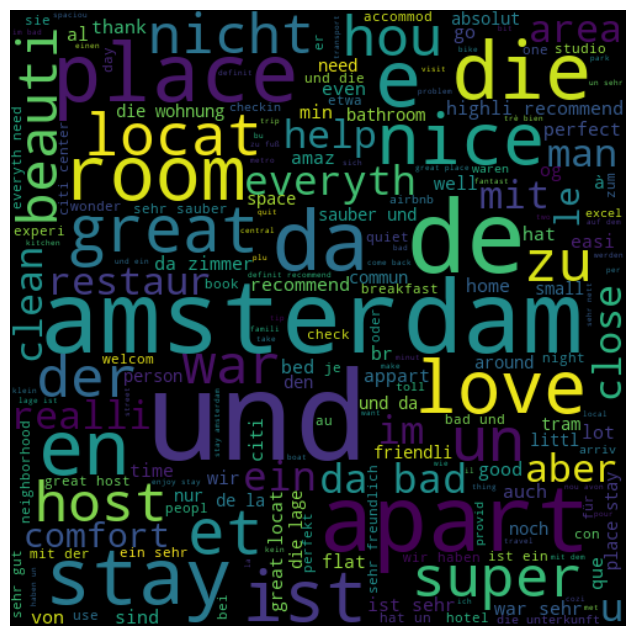

In [55]:
all_words = ' '.join([text for text in df['clean_comments']])
word_count = WordCloud(width=500, height=500, random_state=12, max_font_size=100).generate(all_words)

plt.figure(figsize=(10,8))
plt.imshow(word_count, interpolation="bilinear")
plt.axis('off')
plt.show()

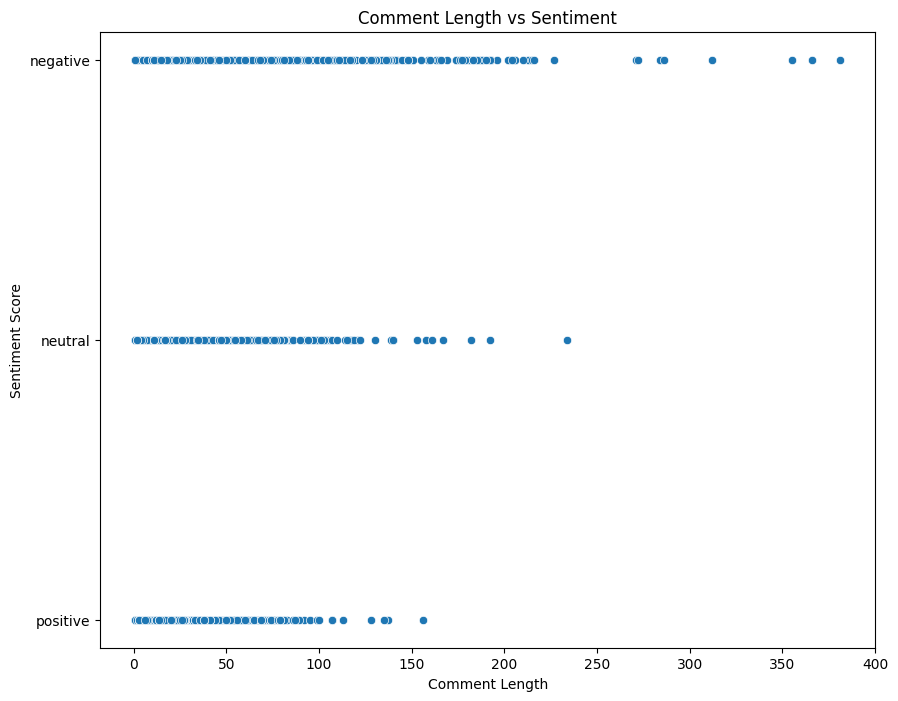

In [56]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='comment_length', y='sentiment', data=data)
plt.title('Comment Length vs Sentiment')
plt.xlabel('Comment Length')
plt.ylabel('Sentiment Score')
plt.show()

In [57]:
#Top 20 reviewer
top_reviewer = data['reviewer_name'].value_counts().head(20).index
top_reviewer_df = data[data['reviewer_name'].isin(top_reviewer)]

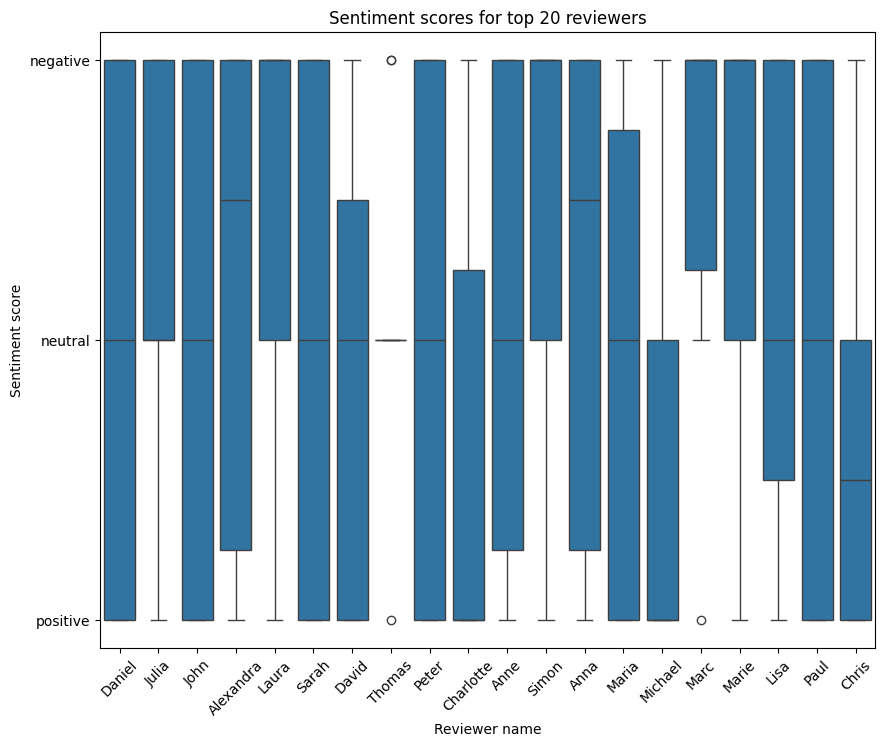

In [58]:
plt.figure(figsize=(10,8))
sns.boxplot(x='reviewer_name', y='sentiment', data=top_reviewer_df)
plt.xticks(rotation=45)
plt.title('Sentiment scores for top 20 reviewers')
plt.xlabel('Reviewer name')
plt.ylabel('Sentiment score')
plt.show()

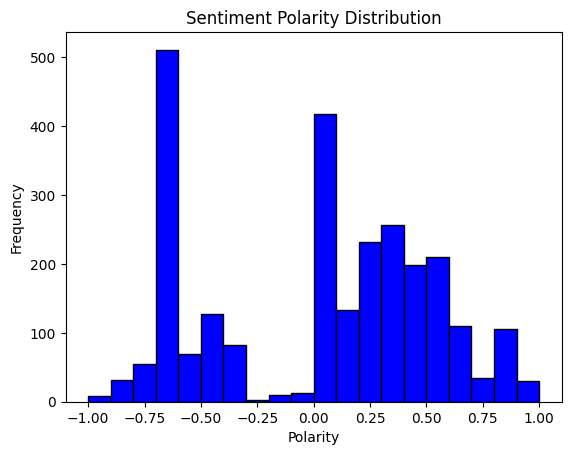

In [59]:
plt.hist(data['polarity'], bins=20, color='blue', edgecolor='black')
plt.title('Sentiment Polarity Distribution')
plt.xlabel('Polarity')
plt.ylabel('Frequency')
plt.show()

In [60]:
vectorization = TfidfVectorizer()
X = vectorization.fit_transform(data['clean_comments'])

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, data['sentiment'], test_size=0.2, random_state=42)

In [62]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 64121 stored elements and shape (2112, 13555)>

In [63]:
X_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 17090 stored elements and shape (528, 13555)>

In [64]:
y_train

2402    positive
1194     neutral
2411    positive
440     negative
508     negative
          ...   
1653     neutral
1101     neutral
1137     neutral
1304     neutral
860     negative
Name: sentiment, Length: 2112, dtype: object

In [65]:
y_test

2020    positive
32      negative
964      neutral
1474     neutral
478     negative
          ...   
2048    positive
279     negative
2458    positive
2371    positive
1808    positive
Name: sentiment, Length: 528, dtype: object

In [66]:
#Logistic Regression
LR = LogisticRegression()
LR.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [67]:
lr_pred = LR.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred, average='weighted')
lr_rec = recall_score(y_test, lr_pred, average='weighted')
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

In [68]:
print(f"Model Type: {LR}")
#print("\n" + f"Prediciton: {lr_pred}")
#print('-' * 50)

print(f"Accuracy Score:  {(lr_acc):%}")
print(f"Precision Score: {(lr_prec):%}")
print(f"Recall Score:    {(lr_rec):%}")
print(f"F1-Score:        {(lr_f1):%}")

Model Type: LogisticRegression()
Accuracy Score:  78.787879%
Precision Score: 78.734146%
Recall Score:    78.787879%
F1-Score:        78.690187%


In [73]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

    negative       0.80      0.87      0.84       178
     neutral       0.72      0.69      0.70       177
    positive       0.84      0.80      0.82       173

    accuracy                           0.79       528
   macro avg       0.79      0.79      0.79       528
weighted avg       0.79      0.79      0.79       528



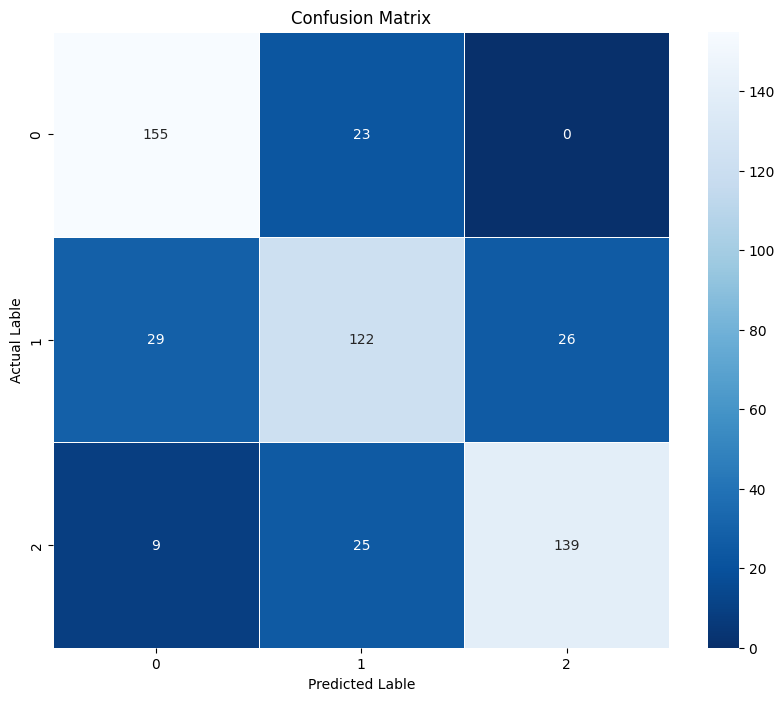

In [70]:
lr_confusion_matrix = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(10,8))
sns.heatmap(lr_confusion_matrix, annot=True, fmt='.0f', linewidths=0.5, square=True, cmap='Blues_r')
plt.ylabel('Actual Lable')
plt.xlabel('Predicted Lable')
plt.title('Confusion Matrix')
plt.show()

In [119]:
mkdir Models

A subdirectory or file Models already exists.


In [82]:
joblib.dump(LR, 'Models/Logic_Reg_model.pkl')

['Models/Logic_Reg_model.pkl']

In [71]:
#Trying with KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
knn_prec = precision_score(y_test, knn_pred, average='weighted')
knn_recall = recall_score(y_test, knn_pred, average='weighted')
knn_f1= f1_score(y_test, knn_pred, average='weighted')

In [72]:
print(f"Model Type: {knn}")

print(f"Accuracy Score:  {(knn_acc):%}")
print(f"Precision Score: {(knn_prec):%}")
print(f"Recall Score:    {(knn_recall):%}")
print(f"F1-Score:        {(knn_f1):%}")

Model Type: KNeighborsClassifier()
Accuracy Score:  61.174242%
Precision Score: 65.686701%
Recall Score:    61.174242%
F1-Score:        61.856992%


In [74]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

    negative       0.76      0.63      0.69       178
     neutral       0.47      0.68      0.55       177
    positive       0.75      0.52      0.61       173

    accuracy                           0.61       528
   macro avg       0.66      0.61      0.62       528
weighted avg       0.66      0.61      0.62       528



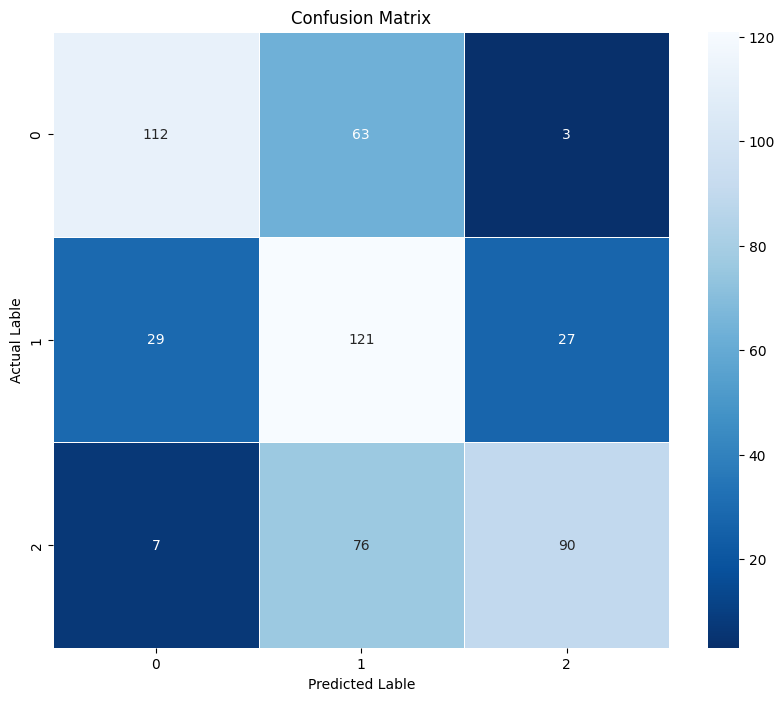

In [75]:
knn_confusion_matrix = confusion_matrix(y_test, knn_pred)
plt.figure(figsize=(10,8))
sns.heatmap(knn_confusion_matrix, annot=True, fmt='.0f', linewidths=0.5, square=True, cmap='Blues_r')
plt.ylabel('Actual Lable')
plt.xlabel('Predicted Lable')
plt.title('Confusion Matrix')
plt.show()

In [80]:
joblib.dump(knn, 'Models/k_neighbors_model.pkl')

['Models/k_neighbors_model.pkl']

In [76]:
#Trying with Decision Tree
dtr = DecisionTreeClassifier()
dtr.fit(X_train, y_train)
dtr_pred = dtr.predict(X_test)

dtr_acc = accuracy_score(y_test, dtr_pred)
dtr_prec = precision_score(y_test, dtr_pred, average='weighted')
dtr_recall = recall_score(y_test, dtr_pred, average='weighted')
dtr_f1= f1_score(y_test, dtr_pred, average='weighted')

In [77]:
print(f"Model Type: {dtr}")

print(f"Accuracy Score:  {(dtr_acc):%}")
print(f"Precision Score: {(dtr_prec):%}")
print(f"Recall Score:    {(dtr_recall):%}")
print(f"F1-Score:        {(dtr_f1):%}")

Model Type: DecisionTreeClassifier()
Accuracy Score:  86.363636%
Precision Score: 86.158204%
Recall Score:    86.363636%
F1-Score:        86.230966%


In [78]:
print(classification_report(y_test, dtr_pred))

              precision    recall  f1-score   support

    negative       0.95      0.99      0.97       178
     neutral       0.81      0.77      0.79       177
    positive       0.83      0.83      0.83       173

    accuracy                           0.86       528
   macro avg       0.86      0.86      0.86       528
weighted avg       0.86      0.86      0.86       528



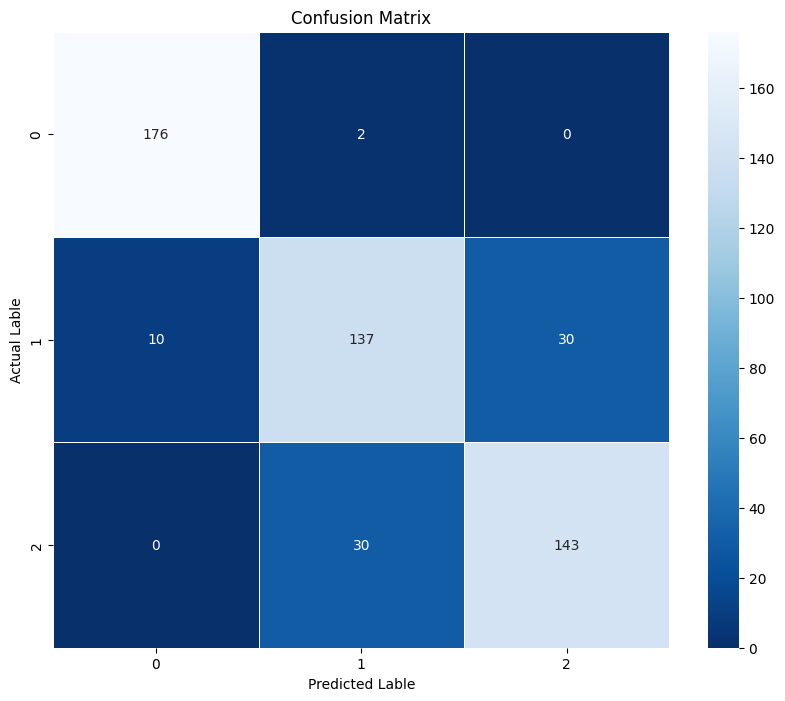

In [87]:
dtr_confusion_matrix = confusion_matrix(y_test, dtr_pred)
plt.figure(figsize=(10,8))
sns.heatmap(dtr_confusion_matrix, annot=True, fmt='.0f', linewidths=0.5, square=True, cmap='Blues_r')
plt.ylabel('Actual Lable')
plt.xlabel('Predicted Lable')
plt.title('Confusion Matrix')
plt.show()

In [83]:
joblib.dump(dtr, 'Models/decision_tree_model.pkl')

['Models/decision_tree_model.pkl']

In [84]:
#Trying with random forest classifier
rdn = RandomForestClassifier()
rdn.fit(X_train, y_train)
rdn_pred = rdn.predict(X_test)

rdn_acc = accuracy_score(y_test, rdn_pred)
rdn_prec = precision_score(y_test, rdn_pred, average='weighted')
rdn_recall = recall_score(y_test, rdn_pred, average='weighted')
rdn_f1= f1_score(y_test, rdn_pred, average='weighted')

In [85]:
print(f"Model Type: {rdn}")

print(f"Accuracy Score:  {(rdn_acc):%}")
print(f"Precision Score: {(rdn_prec):%}")
print(f"Recall Score:    {(rdn_recall):%}")
print(f"F1-Score:        {(rdn_f1):%}")

Model Type: RandomForestClassifier()
Accuracy Score:  76.515152%
Precision Score: 76.352665%
Recall Score:    76.515152%
F1-Score:        76.257849%


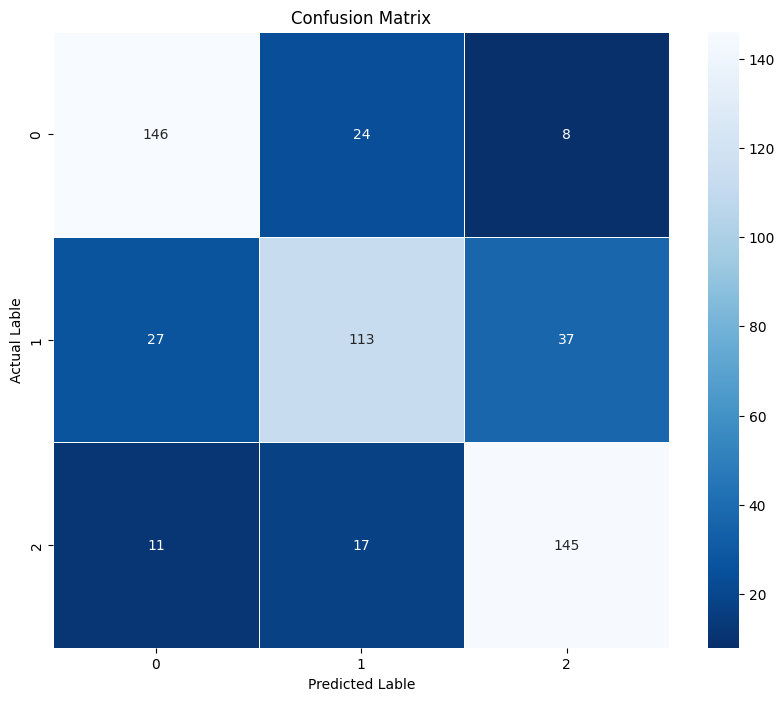

In [88]:
rdn_confusion_matrix = confusion_matrix(y_test, rdn_pred)
plt.figure(figsize=(10,8))
sns.heatmap(rdn_confusion_matrix, annot=True, fmt='.0f', linewidths=0.5, square=True, cmap='Blues_r')
plt.ylabel('Actual Lable')
plt.xlabel('Predicted Lable')
plt.title('Confusion Matrix')
plt.show()

In [90]:
print(classification_report(y_test, rdn_pred))

              precision    recall  f1-score   support

    negative       0.79      0.82      0.81       178
     neutral       0.73      0.64      0.68       177
    positive       0.76      0.84      0.80       173

    accuracy                           0.77       528
   macro avg       0.76      0.77      0.76       528
weighted avg       0.76      0.77      0.76       528



In [91]:
joblib.dump(rdn, 'Models/radom_forest_model.pkl')

['Models/radom_forest_model.pkl']

In [92]:
#Trying with gradient boosting classifier
gbc = GradientBoostingClassifier()
gbc.fit(X_train, y_train)
gbc_pred = gbc.predict(X_test)

gbc_acc = accuracy_score(y_test, gbc_pred)
gbc_prec = precision_score(y_test, gbc_pred, average='weighted')
gbc_recall = recall_score(y_test, gbc_pred, average='weighted')
gbc_f1= f1_score(y_test, gbc_pred, average='weighted')

In [93]:
print(f"Model Type: {gbc}")

print(f"Accuracy Score:  {(gbc_acc):%}")
print(f"Precision Score: {(gbc_prec):%}")
print(f"Recall Score:    {(gbc_recall):%}")
print(f"F1-Score:        {(gbc_f1):%}")

Model Type: GradientBoostingClassifier()
Accuracy Score:  89.772727%
Precision Score: 89.787676%
Recall Score:    89.772727%
F1-Score:        89.778332%


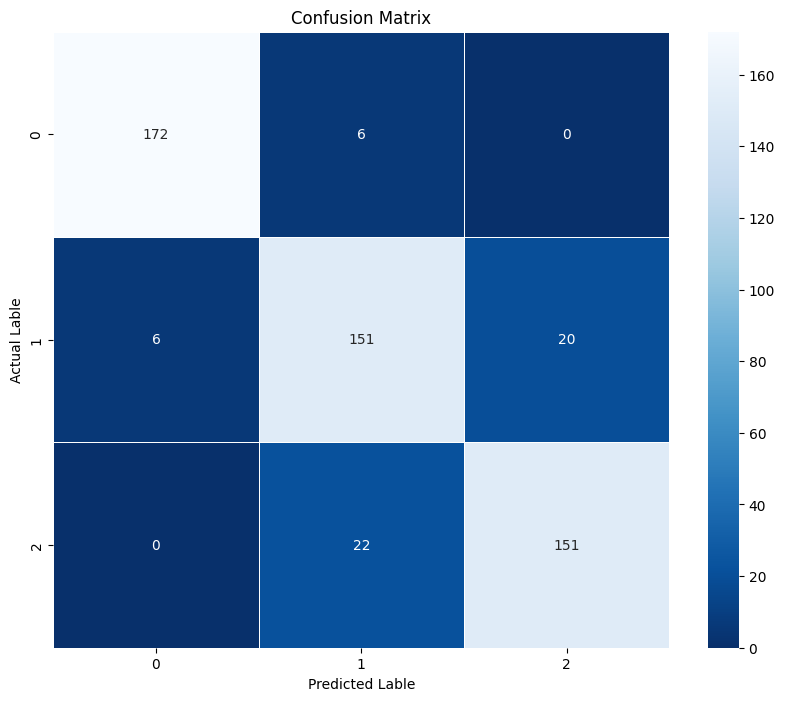

In [94]:
gbc_confusion_matrix = confusion_matrix(y_test, gbc_pred)
plt.figure(figsize=(10,8))
sns.heatmap(gbc_confusion_matrix, annot=True, fmt='.0f', linewidths=0.5, square=True, cmap='Blues_r')
plt.ylabel('Actual Lable')
plt.xlabel('Predicted Lable')
plt.title('Confusion Matrix')
plt.show()

In [95]:
print(classification_report(y_test, gbc_pred))

              precision    recall  f1-score   support

    negative       0.97      0.97      0.97       178
     neutral       0.84      0.85      0.85       177
    positive       0.88      0.87      0.88       173

    accuracy                           0.90       528
   macro avg       0.90      0.90      0.90       528
weighted avg       0.90      0.90      0.90       528



In [96]:
joblib.dump(gbc, 'Models/gradient_boost_model.pkl')

['Models/gradient_boost_model.pkl']

In [97]:
#trying with c-support vector
svc = SVC()
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)

svc_acc = accuracy_score(y_test, svc_pred)
svc_prec = precision_score(y_test, svc_pred, average='weighted')
svc_recall = recall_score(y_test, svc_pred, average='weighted')
svc_f1= f1_score(y_test, svc_pred, average='weighted')

In [98]:
print(f"Model Type: {svc}")

print(f"Accuracy Score:  {(svc_acc):%}")
print(f"Precision Score: {(svc_prec):%}")
print(f"Recall Score:    {(svc_recall):%}")
print(f"F1-Score:        {(svc_f1):%}")

Model Type: SVC()
Accuracy Score:  77.462121%
Precision Score: 78.053716%
Recall Score:    77.462121%
F1-Score:        77.571844%


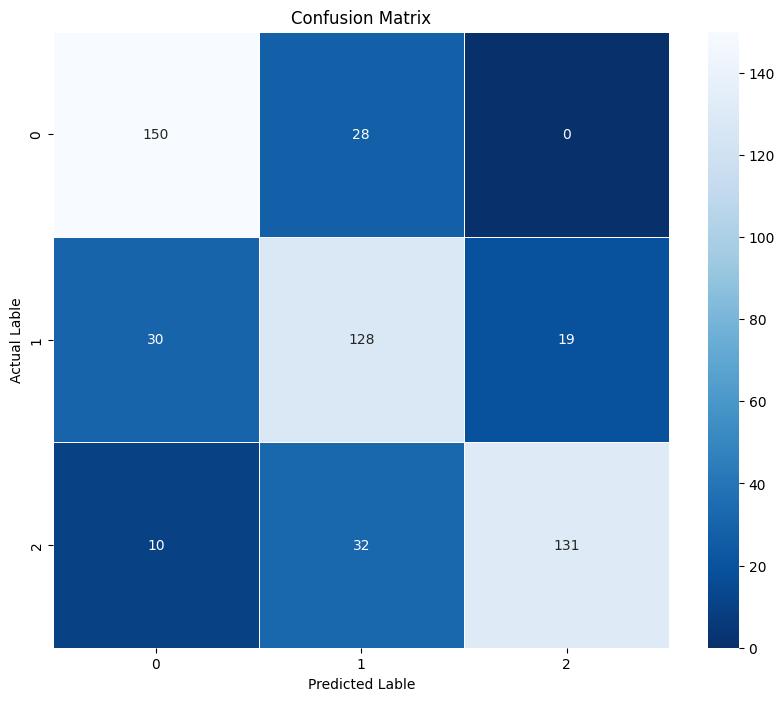

In [99]:
svc_confusion_matrix = confusion_matrix(y_test, svc_pred)
plt.figure(figsize=(10,8))
sns.heatmap(svc_confusion_matrix, annot=True, fmt='.0f', linewidths=0.5, square=True, cmap='Blues_r')
plt.ylabel('Actual Lable')
plt.xlabel('Predicted Lable')
plt.title('Confusion Matrix')
plt.show()

In [103]:
print(classification_report(y_test, svc_pred))

              precision    recall  f1-score   support

    negative       0.79      0.84      0.82       178
     neutral       0.68      0.72      0.70       177
    positive       0.87      0.76      0.81       173

    accuracy                           0.77       528
   macro avg       0.78      0.77      0.78       528
weighted avg       0.78      0.77      0.78       528



In [104]:
joblib.dump(svc, 'Models/support_vector_model.pkl')

['Models/support_vector_model.pkl']

In [105]:
#trying with AdaBoost classifier
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

In [106]:
ada_acc = accuracy_score(y_test, ada_pred)
ada_prec = precision_score(y_test, ada_pred, average='weighted')
ada_recall = recall_score(y_test, ada_pred, average='weighted')
ada_f1= f1_score(y_test, ada_pred, average='weighted')

print(f"Model Type: {ada}")

print(f"Accuracy Score:  {(ada_acc):%}")
print(f"Precision Score: {(ada_prec):%}")
print(f"Recall Score:    {(ada_recall):%}")
print(f"F1-Score:        {(ada_f1):%}")

Model Type: AdaBoostClassifier()
Accuracy Score:  79.734848%
Precision Score: 81.120543%
Recall Score:    79.734848%
F1-Score:        80.138256%


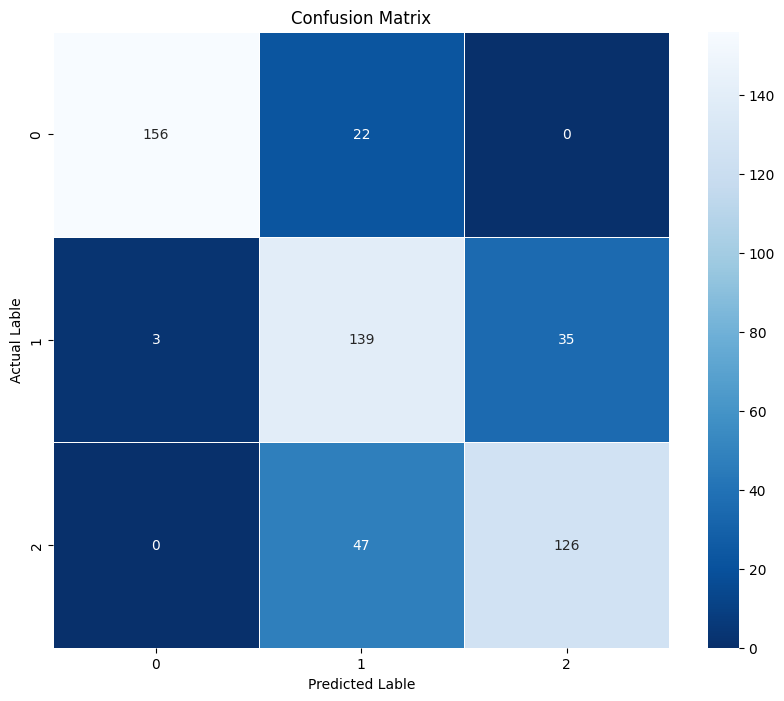

In [107]:
ada_confusion_matrix = confusion_matrix(y_test, ada_pred)
plt.figure(figsize=(10,8))
sns.heatmap(ada_confusion_matrix, annot=True, fmt='.0f', linewidths=0.5, square=True, cmap='Blues_r')
plt.ylabel('Actual Lable')
plt.xlabel('Predicted Lable')
plt.title('Confusion Matrix')
plt.show()

In [108]:
print(classification_report(y_test, ada_pred))

              precision    recall  f1-score   support

    negative       0.98      0.88      0.93       178
     neutral       0.67      0.79      0.72       177
    positive       0.78      0.73      0.75       173

    accuracy                           0.80       528
   macro avg       0.81      0.80      0.80       528
weighted avg       0.81      0.80      0.80       528



In [109]:
joblib.dump(ada, 'Models/adaBoost_model.pkl')

['Models/adaBoost_model.pkl']

In [118]:
ada_scores = [ada_acc*100, ada_prec*100, ada_prec*100, ada_f1*100]
svc_scores = [svc_acc*100, svc_prec*100, svc_prec*100, svc_f1*100]
gbc_scores = [gbc_acc*100, gbc_prec*100, gbc_prec*100, gbc_f1*100]
rdn_scores = [rdn_acc*100, rdn_prec*100, rdn_prec*100, rdn_f1*100]
dtr_scores = [dtr_acc*100, dtr_prec*100, dtr_prec*100, dtr_f1*100]
knn_scores = [knn_acc*100, knn_prec*100, knn_prec*100, knn_f1*100]
lr_scores = [lr_acc*100, lr_prec*100, lr_prec*100, lr_f1*100]

x_axis = ['Accuracy', 'Precision', 'Recall', 'F1']
y_axis = [value for value in range(1, 120, 10)]
xpos = np.arange(len(x_axis))
bar_width = .10

plt.figure(figsize=(20, 10), dpi=700, facecolor='w', edgecolor='k')
plt.title('Machine Learning Model Scores')

def labels(bars):
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, h,
                f'{h:.2f}%', ha='center', va='bottom', rotation=90)
bars_lr  = plt.bar(xpos - 3*bar_width, lr_scores,  width=bar_width, label="Logistic Regression")
bars_knn = plt.bar(xpos - 2*bar_width, knn_scores, width=bar_width, label="K-Neighbor")
bars_dtr = plt.bar(xpos - 1*bar_width, dtr_scores, width=bar_width, label="Decision Tree")
bars_rdn = plt.bar(xpos,                rdn_scores, width=bar_width, label="Random Forest")
bars_gbc = plt.bar(xpos + 1*bar_width, gbc_scores, width=bar_width, label="Gradient Boosting")
bars_svc = plt.bar(xpos + 2*bar_width, svc_scores, width=bar_width, label="Support Vector")
bars_ada = plt.bar(xpos + 3*bar_width, ada_scores, width=bar_width, label="Ada Boost")

# Add labels
for bars in [bars_lr, bars_knn, bars_dtr, bars_rdn, bars_gbc, bars_svc, bars_ada]:
    labels(bars)

# Axes formatting
plt.xticks(xpos, x_axis)
plt.yticks(y_axis)
plt.xlabel("Evaluation Metrics")
plt.ylabel("Percentage")

# Legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()